<a href="https://colab.research.google.com/github/Kenule-dev/Average/blob/master/Final_year_multiple_regression_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intercept: 96.93788364918788
Coefficients: {'SpillVol': np.float64(0.00019537728468244783), 'Distance': np.float64(-0.002820681520865037), 'YrExp': np.float64(-0.26266967031321614), 'SOM': np.float64(-8.5986869737966)}
R² Score: 0.9748770193594691
predicted impact is: [84.14532388 82.05870947 91.41417322 68.66676032 65.09086932 80.23490353]


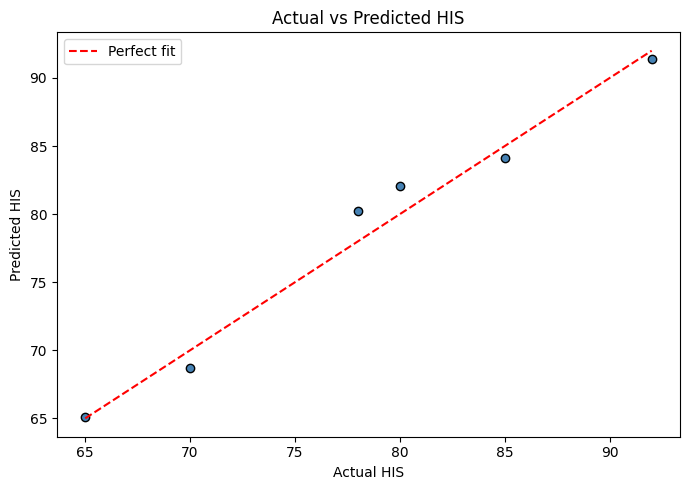

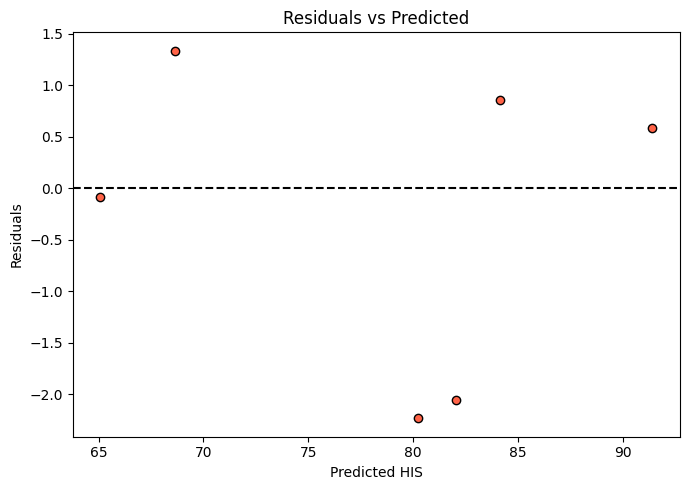

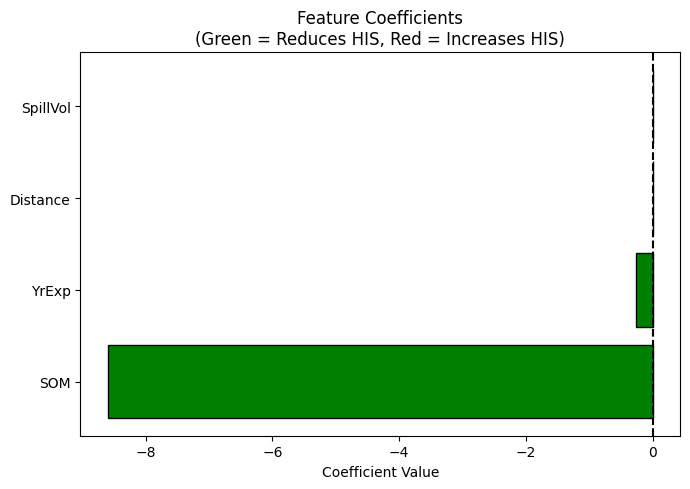

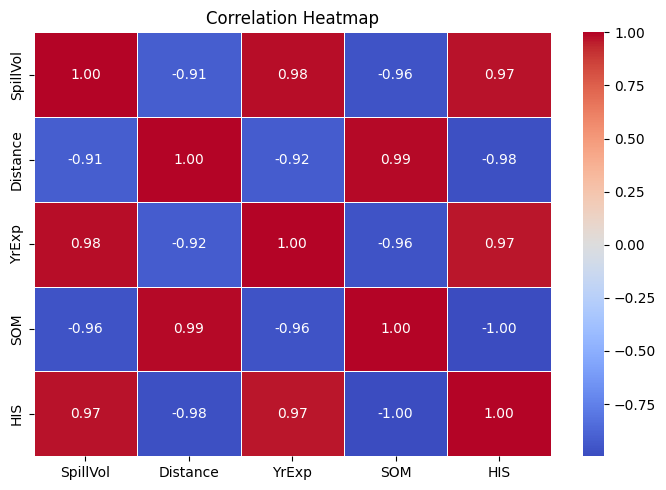

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

oil_spill=pd.read_csv('/content/regression_data.csv')

#print(oil_spill)

X=oil_spill.drop('HIS', axis=1)

Y=oil_spill['HIS']

X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.3, random_state=42)

model=LinearRegression()

model.fit(X_train, Y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("R² Score:", model.score(X_test, Y_test))

Y_pred=model.predict(X_test)

print('predicted impact is:', Y_pred)

plt.figure(figsize=(7, 5))
plt.scatter(Y_test, Y_pred, color='steelblue', edgecolors='black')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label='Perfect fit')
plt.xlabel('Actual HIS')
plt.ylabel('Predicted HIS')
plt.title('Actual vs Predicted HIS')
plt.legend()
plt.tight_layout()
plt.show()
# Points close to the red line = good predictions

# ── 2. Residuals Plot ───────────────────────────────────────────
residuals = Y_test - Y_pred
plt.figure(figsize=(7, 5))
plt.scatter(Y_pred, residuals, color='tomato', edgecolors='black')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted HIS')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()
# Points randomly scattered around 0 = model assumptions are met

# ── 3. Coefficient Bar Chart ────────────────────────────────────
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

colors = ['green' if c < 0 else 'red' for c in coef_df['Coefficient']]
plt.figure(figsize=(7, 5))
plt.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients\n(Green = Reduces HIS, Red = Increases HIS)')
plt.tight_layout()
plt.show()

# ── 4. Correlation Heatmap ──────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(oil_spill.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

